# Access the analysis ready satellite LAI and FAPAR data

This notebook provides an example of how to open the satellite-lai-fapar Zarr store using xarray.
You will need to insert your CDS API key where indicated in the following code cell (available on [your profile page](https://cds.climate.copernicus.eu/profile)).
For more information on using the Data Store Analysis Ready Datasets, please see the [user documentation pages](https://cds.climate.copernicus.eu/datasets/how-to-use-the-dss-arco-dataset).

In [1]:
import os
cdsapi_key = "<INSERT-CDS-API-KEY-HERE>"

# The following attempts to find the CDSAPI key in your environment.
if cdsapi_key == "<INSERT-CDS-API-KEY-HERE>":
    cdsapi_key = None
if cdsapi_key is None:
    cdsapi_key = os.getenv("CDSAPI_KEY")
if cdsapi_key is None and os.path.exists(os.path.expanduser("~/.cdsapirc")):
    with open(os.path.expanduser("~/.cdsapirc"), "r") as f:
        for line in f:
            if line.startswith("key:"):
                cdsapi_key = line.split(":")[1].strip()
                break
if cdsapi_key is None:
    raise ValueError("CDSAPI key not found. Please set the CDSAPI_KEY environment variable or create a ~/.cdsapirc file.")


## Plug and play access

The code below provides a simple plug and play example of how to use the Zarr Store for light-weight access.

In [2]:
import xarray as xr

# Geo-chunked Sentinel-3 data
geochunked_sentinel_3_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-049/arco/satellite_lai_fapar/sentinel-3/geoChunked.zarr"

# Time-chunked Sentinel-3 data
timechunked_sentinel_3_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-049/arco/satellite_lai_fapar/sentinel-3/timeChunked.zarr"

# Geo-chunked SPOT data
geochunked_spot_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-049/arco/satellite_lai_fapar/spot/geoChunked.zarr"

# Time-chunked SPOT data
timechunked_spot_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-049/arco/satellite_lai_fapar/spot/timeChunked.zarr"

# Geo-chunked Proba data
geochunked_proba_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-049/arco/satellite_lai_fapar/proba/geoChunked.zarr"

# Time-chunked Proba data
timechunked_proba_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-049/arco/satellite_lai_fapar/proba/timeChunked.zarr"

# Geo-chunked NOAA-7 data
geochunked_noaa_7_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-049/arco/satellite_lai_fapar/noaa-7/geoChunked.zarr"

# Time-chunked NOAA-7 data
timechunked_noaa_7_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-049/arco/satellite_lai_fapar/noaa-7/timeChunked.zarr"

# Geo-chunked NOAA-9 data
geochunked_noaa_9_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-049/arco/satellite_lai_fapar/noaa-9/geoChunked.zarr"

# Time-chunked NOAA-9 data
timechunked_noaa_9_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-049/arco/satellite_lai_fapar/noaa-9/timeChunked.zarr"

# Geo-chunked NOAA-11 data
geochunked_noaa_11_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-049/arco/satellite_lai_fapar/noaa-11/geoChunked.zarr"

# Time-chunked NOAA-11 data
timechunked_noaa_11_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-049/arco/satellite_lai_fapar/noaa-11/timeChunked.zarr"

# Geo-chunked NOAA-14 data
geochunked_noaa_14_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-049/arco/satellite_lai_fapar/noaa-14/geoChunked.zarr"

# Time-chunked NOAA-14 data
timechunked_noaa_14_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-049/arco/satellite_lai_fapar/noaa-14/timeChunked.zarr"

# Geo-chunked NOAA-16 data
geochunked_noaa_16_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-049/arco/satellite_lai_fapar/noaa-16/geoChunked.zarr"

# Time-chunked NOAA-16 data
timechunked_noaa_16_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-049/arco/satellite_lai_fapar/noaa-16/timeChunked.zarr"

# Geo-chunked NOAA-17 data
geochunked_noaa_17_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-049/arco/satellite_lai_fapar/noaa-17/geoChunked.zarr"

# Time-chunked NOAA-17 data
timechunked_noaa_17_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-049/arco/satellite_lai_fapar/noaa-17/timeChunked.zarr"


# Open the zarr store with xarray, users must insert their API key where indicated.
ds = xr.open_zarr(
    timechunked_sentinel_3_url,
    consolidated=True,
     storage_options = {
        "headers": {"Authorization": f"Bearer {cdsapi_key}"}
    }
)
 
# Inspect the variables
ds

<xarray.Dataset> Size: 64TB
Dimensions:         (time: 234, latitude: 47040, longitude: 120960)
Coordinates:
  * time            (time) datetime64[ns] 2kB 2018-07-10 ... 2024-12-31
  * latitude        (latitude) float64 376kB -60.0 -59.99 -59.99 ... 80.0 80.0
  * longitude       (longitude) float64 968kB -180.0 -180.0 ... 180.0 180.0
Data variables:
    unc_correl      (time, latitude, longitude) float64 11TB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    retrieval_flag  (time, latitude, longitude) float64 11TB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    LAI_ERR         (time, latitude, longitude) float64 11TB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    fAPAR           (time, latitude, longitude) float64 11TB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    fAPAR_ERR       (time, latitude, longitude) float64 11TB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    LAI             (time, latitude, longitude) float64 11TB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>

Plot a map of Leaf Area Index (LAI) from Sentinel-3 data using earthkit-plots.

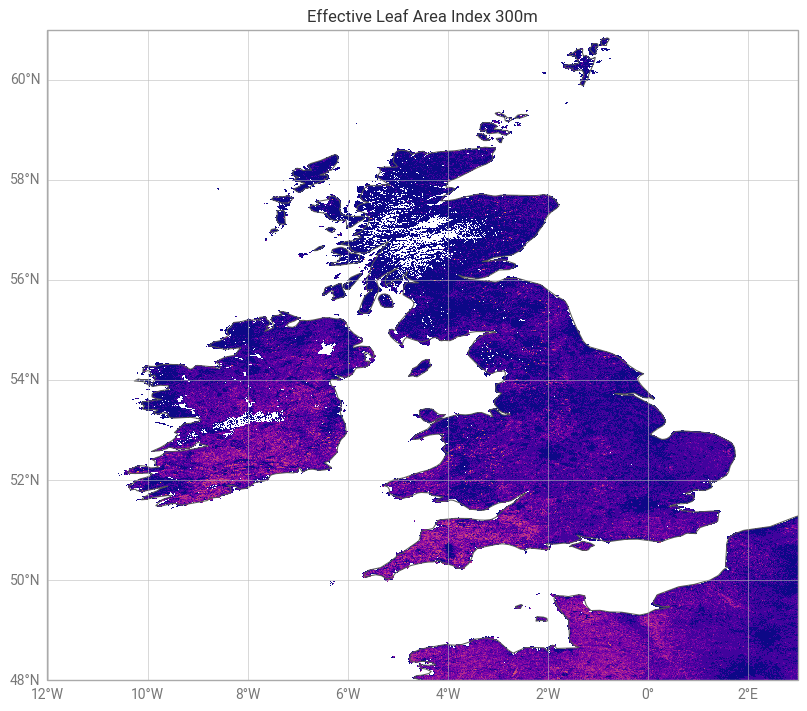

In [3]:
from earthkit import plots as ekp

# Select a single time step to plot
lat_range = (48, 61)
lon_range = (-12, 3)
time_stamp = "2020-01-01"
plot_data = ds["LAI"].sel(time=time_stamp, method="nearest").sel(latitude=slice(*lat_range), longitude=slice(*lon_range)).compute()

chart = ekp.Map()

chart.grid_cells(plot_data)

chart.coastlines()
chart.gridlines()

chart.title("{long_name}")

chart.show()

## Advanced usage

If your workflow requires access to larger amounts of data, it is recommended that you include a retry mechanism.
This is not provided in the current default zarr engine for xarray, instead we can define a custom "`store`" which is
used when connecting to the remote zarr data.

In [4]:
!pip install -q obstore
import xarray as xr
from obstore.store import HTTPStore
from zarr.storage import ObjectStore

# Geo-chunked Sentinel-3 data
geochunked_sentinel_3_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-049/arco/satellite_lai_fapar/sentinel-3/geoChunked.zarr"

# Time-chunked Sentinel-3 data
timechunked_sentinel_3_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-049/arco/satellite_lai_fapar/sentinel-3/timeChunked.zarr"

# Geo-chunked SPOT data
geochunked_spot_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-049/arco/satellite_lai_fapar/spot/geoChunked.zarr"

# Time-chunked SPOT data
timechunked_spot_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-049/arco/satellite_lai_fapar/spot/timeChunked.zarr"

# Geo-chunked Proba data
geochunked_proba_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-049/arco/satellite_lai_fapar/proba/geoChunked.zarr"

# Time-chunked Proba data
timechunked_proba_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-049/arco/satellite_lai_fapar/proba/timeChunked.zarr"

# Geo-chunked NOAA-7 data
geochunked_noaa_7_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-049/arco/satellite_lai_fapar/noaa-7/geoChunked.zarr"

# Time-chunked NOAA-7 data
timechunked_noaa_7_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-049/arco/satellite_lai_fapar/noaa-7/timeChunked.zarr"

# Geo-chunked NOAA-9 data
geochunked_noaa_9_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-049/arco/satellite_lai_fapar/noaa-9/geoChunked.zarr"

# Time-chunked NOAA-9 data
timechunked_noaa_9_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-049/arco/satellite_lai_fapar/noaa-9/timeChunked.zarr"

# Geo-chunked NOAA-11 data
geochunked_noaa_11_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-049/arco/satellite_lai_fapar/noaa-11/geoChunked.zarr"

# Time-chunked NOAA-11 data
timechunked_noaa_11_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-049/arco/satellite_lai_fapar/noaa-11/timeChunked.zarr"

# Geo-chunked NOAA-14 data
geochunked_noaa_14_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-049/arco/satellite_lai_fapar/noaa-14/geoChunked.zarr"

# Time-chunked NOAA-14 data
timechunked_noaa_14_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-049/arco/satellite_lai_fapar/noaa-14/timeChunked.zarr"

# Geo-chunked NOAA-16 data
geochunked_noaa_16_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-049/arco/satellite_lai_fapar/noaa-16/geoChunked.zarr"

# Time-chunked NOAA-16 data
timechunked_noaa_16_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-049/arco/satellite_lai_fapar/noaa-16/timeChunked.zarr"

# Geo-chunked NOAA-17 data
geochunked_noaa_17_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-049/arco/satellite_lai_fapar/noaa-17/geoChunked.zarr"

# Time-chunked NOAA-17 data
timechunked_noaa_17_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-049/arco/satellite_lai_fapar/noaa-17/timeChunked.zarr"


# Use obstore's HTTPStore to create a store with retry configuration,
# and then wrap it in a zarr ObjectStore to read with xarray.
# See https://github.com/developmentseed/obstore/blob/main/obstore/python/obstore/_store/_retry.pyi
# for more details on the retry configuration options.
http_store = HTTPStore(
    geochunked_sentinel_3_url,
    client_options={
        "default_headers": {"Authorization": f"Bearer {cdsapi_key}"},
    },
)
store = ObjectStore(http_store, read_only=True)
ds = xr.open_zarr(store)
ds

<xarray.Dataset> Size: 64TB
Dimensions:         (time: 234, latitude: 47040, longitude: 120960)
Coordinates:
  * time            (time) datetime64[ns] 2kB 2018-07-10 ... 2024-12-31
  * latitude        (latitude) float64 376kB -60.0 -59.99 -59.99 ... 80.0 80.0
  * longitude       (longitude) float64 968kB -180.0 -180.0 ... 180.0 180.0
Data variables:
    unc_correl      (time, latitude, longitude) float64 11TB dask.array<chunksize=(32, 128, 256), meta=np.ndarray>
    retrieval_flag  (time, latitude, longitude) float64 11TB dask.array<chunksize=(32, 128, 256), meta=np.ndarray>
    LAI_ERR         (time, latitude, longitude) float64 11TB dask.array<chunksize=(32, 128, 256), meta=np.ndarray>
    fAPAR           (time, latitude, longitude) float64 11TB dask.array<chunksize=(32, 128, 256), meta=np.ndarray>
    fAPAR_ERR       (time, latitude, longitude) float64 11TB dask.array<chunksize=(32, 128, 256), meta=np.ndarray>
    LAI             (time, latitude, longitude) float64 11TB dask.array<chunksize=(32, 128, 256), meta=np.ndarray>

The result is the same as the previous example, this just provides a more robust connection, preventing your
workflow crashing due to temporary network issues.